80000000000.0
supression= 0.930860647776277
a_end= 279258194332883.1


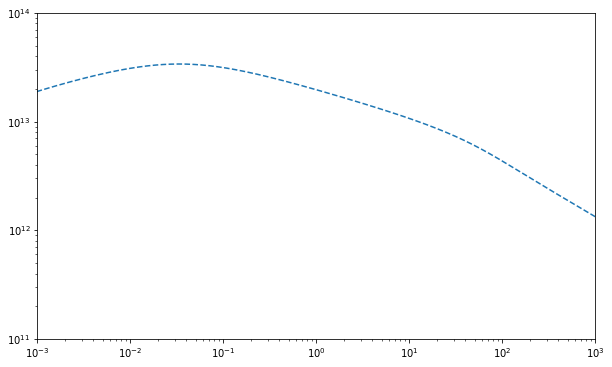

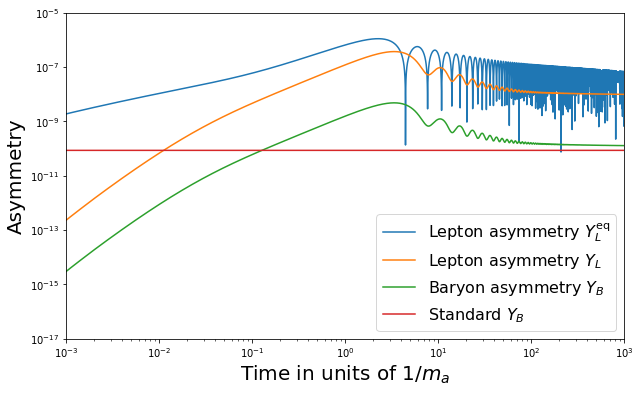

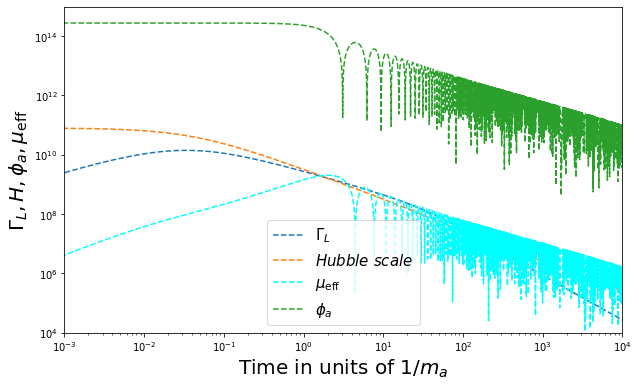

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import zeta

# Compute Riemann zeta function at s = 3
zeta_3 = zeta(3)
#print(zeta_3)  # Output: 1.2020569031595942

# Define constants
Mpl = 2.4e18  # Reduced Planck mass in GeV
fa = 3.0e14  # Axion decay constant in GeV
ma = 5.0e9 #7.0e10 # Axion mass in GeV (from paper)
Gamma_phi = 2.4e8 # Fixed inflaton decay rate in GeV

sigma_eff= 1.0e-31

# Hubble parameter during inflation
H_inf = 8.0e10 # Given Hubble rate during inflation in GeV

print(H_inf)
# Compute initial inflaton energy density using H_inf
rho_phi0 = 3 * Mpl**2 * H_inf**2
rho_R0 = 1e-40 * rho_phi0  # Small initial radiation density
n_L0 = 0  # Initial lepton asymmetry

# Relativistic degrees of freedom in early universe
g_star = 106.75

# Parameters for lepton number violation
#Gamma_0 = 1e-3  # Order of magnitude estimate for lepton violation rate
#p = 1  # Power-law index for lepton violation
C_const = 4 / np.pi**2  # Prefactor from Equation (9)
lam = (3/2)*(1-np.sqrt(1-4.0*ma**2/(9.0*H_inf**2)))
sup= np.exp(-lam*55)
print("supression=", sup)
# Initial conditions
a0 =sup*fa # Initial axion field displacement
dot_a0 = 0 #0.5  # Initial axion velocity

print("a_end=", a0)
# Define the system of equations including n_L evolution using Eq. (9)
def equations(t, y):
    a, dot_a, rho_phi, rho_R, n_L = y
    
    # Hubble parameter
    rho_total = rho_phi + rho_R #+ 0.5 * dot_a**2 + 0.5 * ma**2 * a**2
    H = np.sqrt(rho_total / (3 * Mpl**2))

    # Axion evolution equations
    d_a_dt = dot_a
    d_dot_a_dt = -3 * H * dot_a - ma**2 * a

    # Energy density evolution
    d_rho_phi_dt = -3 * H * rho_phi - Gamma_phi * rho_phi
    d_rho_R_dt = -4 * H * rho_R + Gamma_phi * rho_phi  # Energy transfer from inflaton decay

    # Compute lepton asymmetry evolution using Equation (9)
    mu_eff = dot_a / fa  # Effective chemical potential
    T_sq = (30 / (np.pi**2 * g_star) * rho_R) ** (1/2)  # Temperature squared proportional to radiation energy density
    n_L_eq = 4*C_const * mu_eff * T_sq  # Equation (8) from the paper

    # Lepton violation rate
    T = np.sqrt(T_sq)  # Temperature estimate
    n_l_eq = 2*T**3/np.pi**2
    Gamma_L = 4*n_l_eq*sigma_eff #if T > 10e13 else 0
   # Gamma_L = Gamma_0 * (T / Mpl) ** p  # Power-law suppression

    # Evolution of n_L (Eq. 9 from the paper)
    d_nL_dt = -3 * H * n_L - Gamma_L *( n_L -n_L_eq)#+ C_const * mu_eff * T_sq

    return [d_a_dt, d_dot_a_dt, d_rho_phi_dt, d_rho_R_dt, d_nL_dt]

# Time in units of 1/m_a
tau_min, tau_max = 1e-4, 1e4  # Time range in units of 1/m_a
t_eval = np.logspace(np.log10(tau_min), np.log10(tau_max), 10000) / ma

#a0 = fa*np.exp(-t_eval*ma**2/3.0*H_inf**2)
#dot_a0 = (-fa*ma**2/3.0*H_inf**2)*np.exp(-t_eval*ma**2/3.0*H_inf**2)

# Solve the system using Radau (stiff solver)
y0 = [a0, dot_a0, rho_phi0, rho_R0, n_L0]
sol = solve_ivp(equations, (tau_min / ma, tau_max / ma), y0, method='Radau', t_eval=t_eval)

# Extract numerical solution
t_scaled = np.array(sol.t) * ma
#t_scaled = sol.t * ma  # Convert time to units of 1/m_a
n_L_numerical = sol.y[4]

# Compute n_L^eq using Eq. (8)
a_numerical =sol.y[0]
dot_a_numerical = sol.y[1]
rho_R_numerical = sol.y[3]
rho_R_numerical = np.maximum(rho_R_numerical, 1e-30)
rho_phi_numerical =sol.y[2]
mu_eff_numerical = dot_a_numerical / fa
T_sq_numerical = (30 / (np.pi**2 * g_star) * rho_R_numerical) ** (1/2)
n_L_eq_numerical = C_const * mu_eff_numerical * T_sq_numerical

n_l_eq_numerical = 2*(T_sq_numerical**(3/2))/np.pi**2
Gamma_L_numerical = 18*n_l_eq_numerical*sigma_eff
#4*n_L_eq_numerical*sigma_eff #Gamma_L_numerical = Gamma_0 * (np.sqrt(T_sq_numerical) / Mpl) ** p

rho_a_numerical =0.5 * dot_a_numerical**2 + 0.5 * ma**2 * a_numerical**2
rho_tot_numerical =rho_R_numerical+rho_phi_numerical#+rho_a_numerical
H_numerical= np.sqrt(rho_tot_numerical/(3*Mpl**2))
a_dot_a_ratio =dot_a_numerical/a_numerical
#print("rho_a", rho_a_numerical)
#print("H_numerical", H_numerical)
#print("Gamma_L", Gamma_L_numerical)


# Compute entropy density s = (2 pi^2 / 45) g_star * T^3 ~ g_star * rho_R^(3/4)
s_entropy = (2 * np.pi**2 / 45) * g_star * (T_sq_numerical**(3/2))
# Compute photon number density
#n_gamma = (2 * zeta_3 / np.pi**2) * np.maximum(rho_R_numerical, 1e-30)**(3/4)

# Compute normalized lepton asymmetry n_L / s and n_L^eq / s
n_L_normalized = n_L_numerical / s_entropy# / n_gamma
n_L_eq_normalized = n_L_eq_numerical/s_entropy # / n_gamma
n_B_numerical =  0.013*n_L_normalized # / n_gamma
eta_b_std = 8.5e-11

# Plot (n_L / s) and (n_L^eq / s) in the same figure (to match Figure 1)
plt.figure(figsize=(10, 6))
plt.loglog(t_scaled, np.abs(np.sqrt(T_sq_numerical)), label=r"Temperature$", linestyle='--')
plt.xlim([10e-4, 10e2])
plt.ylim([10e10, 10e13])
plt.savefig('temperature.png')

plt.figure(figsize=(10, 6))
plt.loglog(t_scaled, np.abs(n_L_eq_normalized), label=r"Lepton asymmetry $Y^{\rm eq}_L$", linestyle='-')
plt.loglog(t_scaled, np.abs(n_L_normalized), label=r"Lepton asymmetry $Y_L$", linestyle='-')
plt.loglog(t_scaled, np.abs(n_B_numerical), label=r"Baryon asymmetry $Y_B$", linestyle='-')
#plt.loglog(t_scaled, np.abs(eta_b_std), label=r"Standard $Y_B$", linestyle='-')
plt.loglog(t_scaled, np.full_like(t_scaled, eta_b_std), label=r"Standard $Y_B$", linestyle='-')
plt.xlim([10e-4, 10e2])
plt.ylim([10e-18, 10e-6])


plt.xlabel("Time in units of $1/m_a$",fontsize=20)
plt.ylabel("Asymmetry",fontsize=20)
plt.legend(fontsize=16)
#plt.title("Evolution of Normalized Lepton and Baryon  Asymmetry")
#plt.grid(False,linewidth = "1.0")
plt.savefig('eta_B.png')
plt.show()

#plt.figure(figsize=(10, 6))
#plt.loglog(t_scaled, np.abs(rho_R_numerical), label=r"$\rho_R$", linestyle='--')
#plt.loglog(t_scaled, np.abs(rho_phi_numerical), label=r"$\rho_\phi$", linestyle='--')

#plt.xlabel("Time in units of $1/m_a$")
#plt.ylabel("Normalized Lepton Asymmetry $Y_L$")
#plt.legend()
#plt.title("Evolution of Normalized Lepton Asymmetry $Y_B$ (Numerical)")
#plt.grid(True)
#plt.show()

plt.figure(figsize=(10, 6))
plt.loglog(t_scaled, np.abs(Gamma_L_numerical), label=r"$\Gamma_{L}$", linestyle='--')
plt.loglog(t_scaled, np.abs(H_numerical), label=r"$Hubble ~scale$", linestyle='--')
plt.loglog(t_scaled, np.abs(mu_eff_numerical),  color='cyan', label=r"$\mu_{\rm eff}$", linestyle='--')
plt.loglog(t_scaled, np.abs(a_numerical), label=r"$\phi_a$", linestyle='--')
plt.xlim([10e-4, 10e3])
plt.ylim([10e3, 10e14])

plt.xlabel("Time in units of $1/m_a$",fontsize=20)
plt.ylabel("$\Gamma_L, H,\phi_a, \mu_{\mathrm{eff}}$",fontsize=20)
plt.legend(fontsize=15)
#plt.title("$Gamma_L, H, \frac{\dot{a}}{a}$")
plt.grid(False)
plt.savefig('H-adot-GammaL.png')
plt.show()
